# IT Salary Analysis

This project explores salary trends across the tech industry, analyzing how factors like job role, experience level, education, company size, and region influence compensation. The goal is to extract meaningful insights from raw data and present them in a clear, visual way.

The dataset contains salary records from multiple IT roles including Software Engineers, Data Scientists, DevOps, Cloud Engineers, and more. The analysis covers data cleaning and preprocessing, salary distribution by role and seniority, regional and country-based comparisons, impact of company size and remote work on compensation, and correlation between education level and salary.

Built with Python, Pandas, Matplotlib, Seaborn, and Jupyter Notebook.
To run the project, clone the repository, install the dependencies with `pip install -r requirements.txt`, and open `analysis.ipynb` in Jupyter. Key findings and charts are documented directly inside the notebook with comments explaining each step.

## Analytical Questions

- Does salary grow consistently with `experience_years`, or is there a saturation point?

- Does `education_level` significantly impact salary, or is it secondary compared to job role?

- At what point does `skills_count` start generating noticeable salary increases?

- Which industries offer the highest salaries, and how does this vary by location?

- Does remote work versus on-site work affect salary within the same experience level?

- Do certifications increase salary independently of experience?


In [68]:
import sys
# install if necessary: !{sys.executable} -m pip install matplotlib seaborn 

In [18]:
import pandas as pd
import numpy as np
def install_math_sns():
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
    except Exception as e:
        import sys
        !{sys.executable} -m pip install matplotlib seaborn 
        
install_math_sns()
sns.set_style("darkgrid")

## Loading the Dataset
m
Loading the dataset from a CSV file using Pandas. A helper function handles the file reading with basic error handling in case the file is not found. Display options are configured to show all columns and rows without truncation.

In [200]:
def data():
    try:
        df = pd.read_csv('data/job_salary.csv')
        pd.set_option('display.max_columns', None)
        pd.set_option('display.max_rows', None)
        return df
    except FileNotFoundError as e:
        print(f'File not found, {e}')
        
df = data()
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


## Exploratory Data Analysis

Initial exploration of the dataset to understand its structure, data types, missing values, and overall distribution. This step provides a first look at the data before any cleaning or transformation is applied.

In [201]:
def unique_data(df: pd.Series):
    col_unique = {}
    for data in df.columns:
        col_unique[data] = df[data].unique()
    return col_unique
    
def unique_data_color_and_job(df: pd.Series):
    jobs = unique_data(df)["job_title"]
    cores = sns.color_palette("tab10", len(jobs))
    data = [(x, y) for x, y in zip(jobs, cores)]
    return data

# unique_data(df)
# unique_data_color_and_job(df)

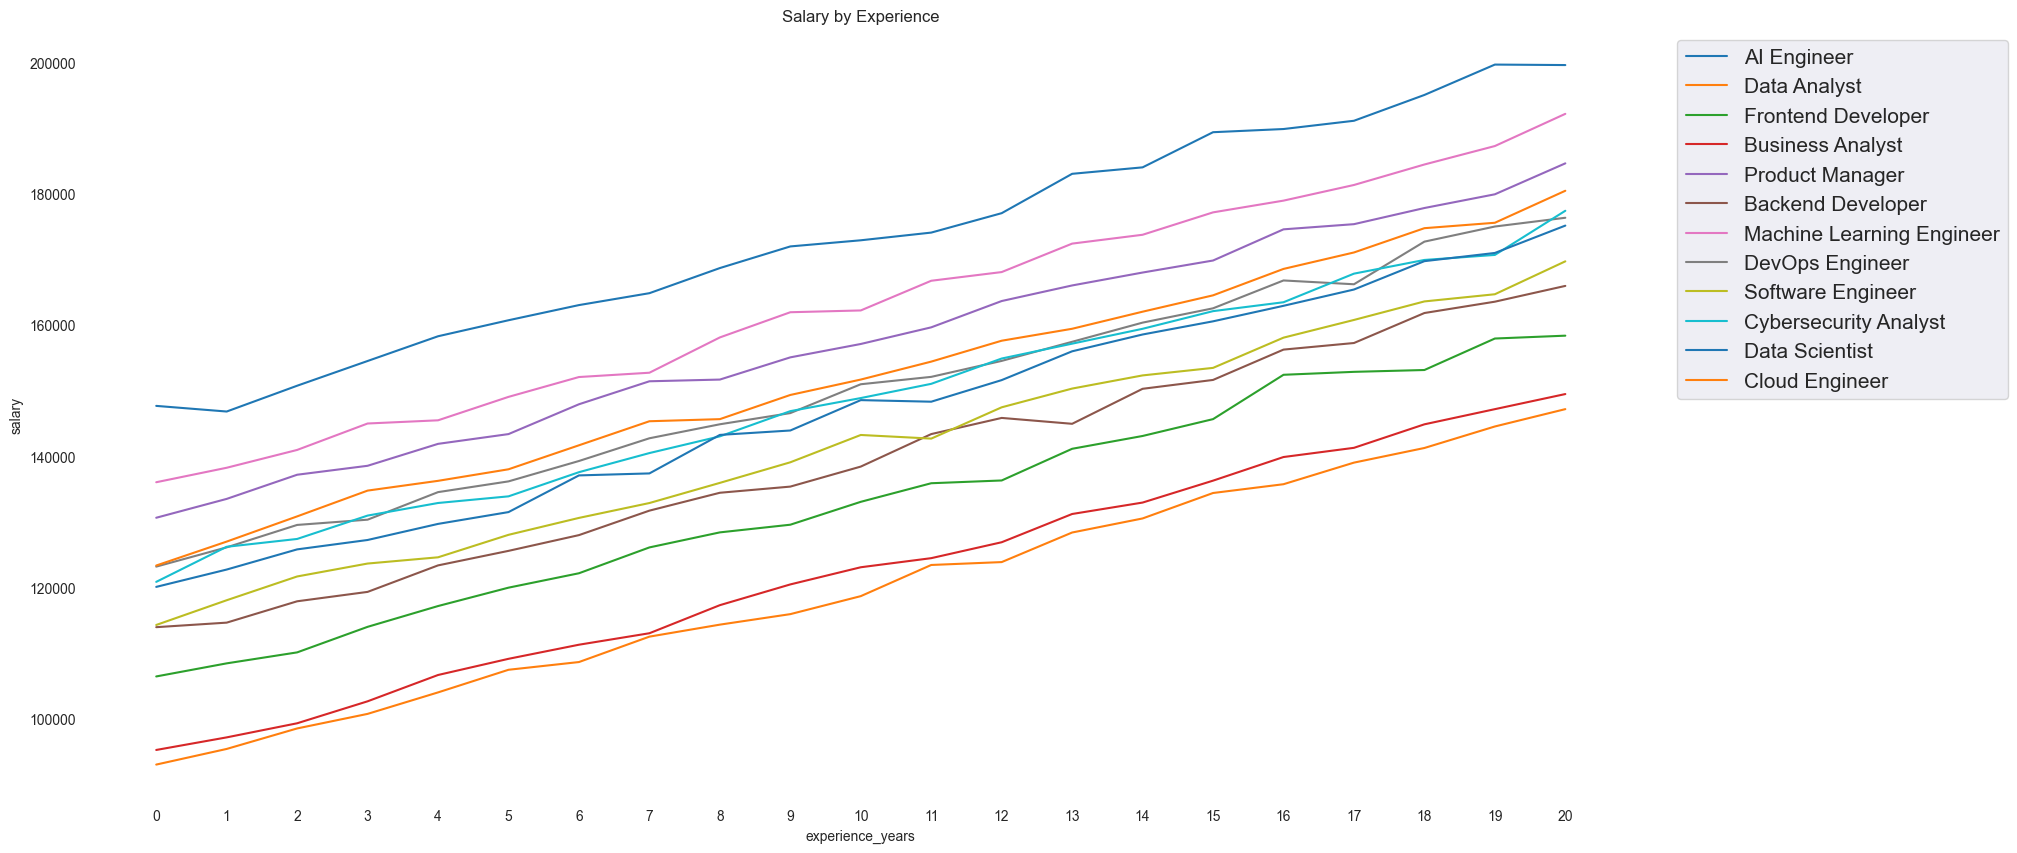

In [202]:
def salary_and_experience(df: pd.DataFrame):  
    plt.figure(figsize=(20,10))
    
    #separando todas as profissoes e escolhendo uma cor em formato RGB
    data = unique_data_color_and_job(df)
    
    plt.title("Salary by Experience")
    
    # plotando os graficos usando a tupla gerada no 'data'
    for job, color in data:
        jobs = df[df["job_title"] == job]
    
        sns.lineplot(
            data=jobs,
            x="experience_years",
            y="salary",
            color=color,
            label=job,
            errorbar=None
        )
    
    plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=15
    )
    
    plt.xticks(range(
        df["experience_years"].min(),
        df["experience_years"].max() + 1,
        1
    ))
    
    plt.box(False)
    plt.show()
    
salary_and_experience(df)

Salaries generally rise with experience, but most roles eventually reach a saturation point where growth slows, while highly specialized fields like AI Engineering and Machine Learning continue to scale upward without a clear ceiling.


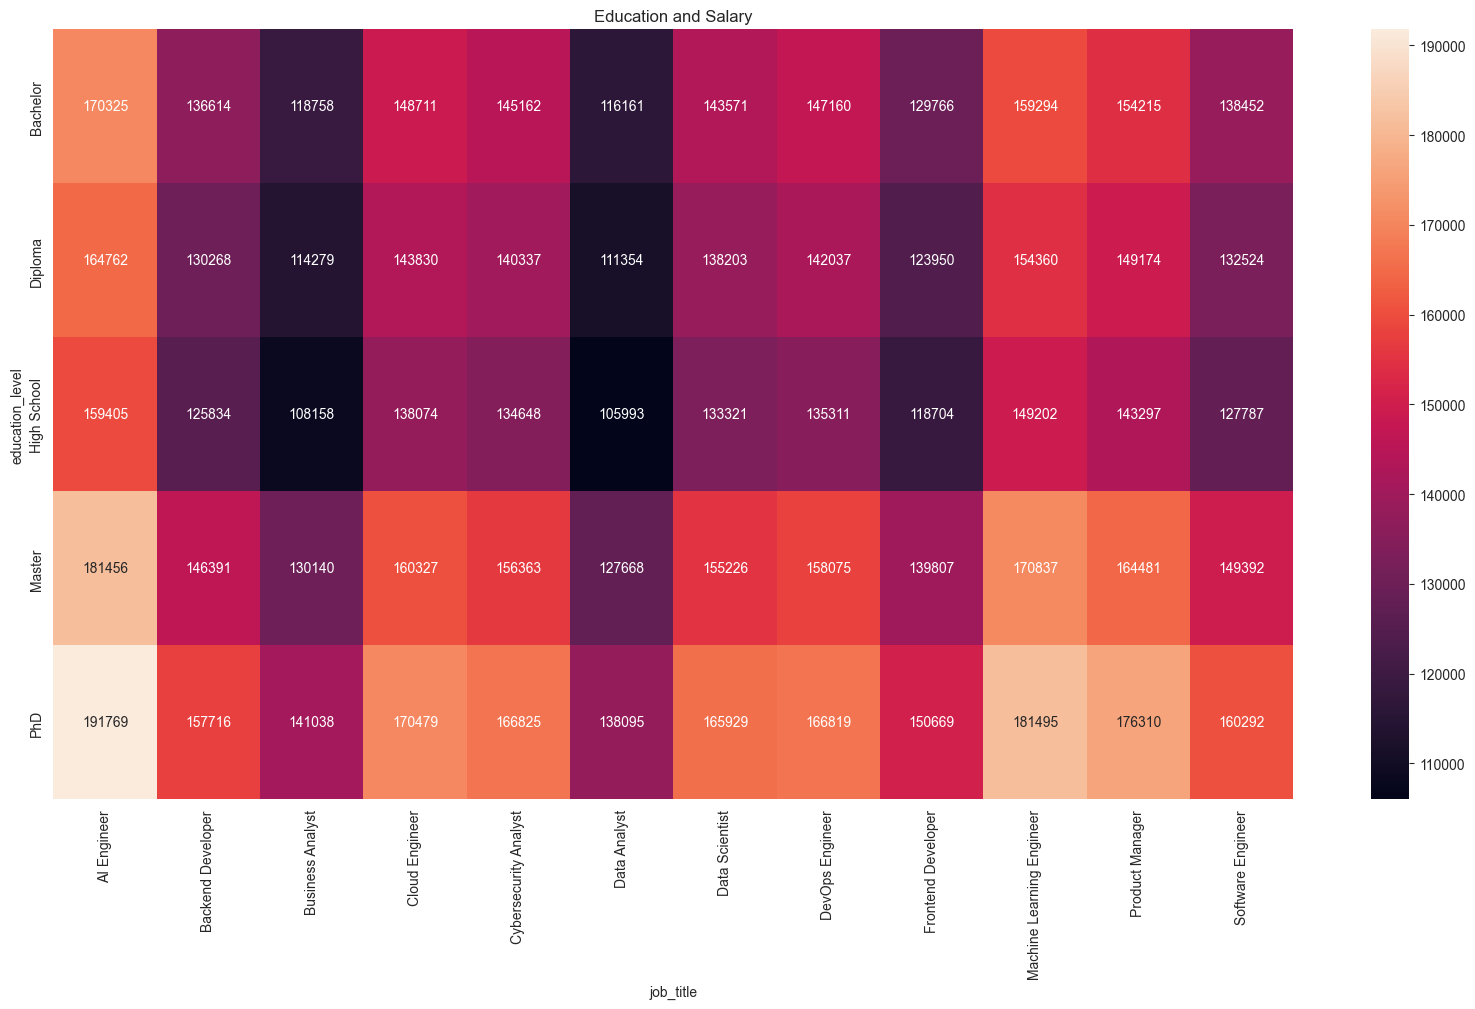

In [203]:
def education_level_salary(df: pd.DataFrame):
    plt.figure(figsize=(20,10))
    data = unique_data_color_and_job(df)
    plt.title("Education and Salary")
    
    pivot = df.pivot_table(
        values="salary",
        index="education_level",
        columns="job_title",
        aggfunc="mean"
    )
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f"
    )
    
    plt.show()
    
education_level_salary(df)


Education level does have a measurable impact on salary, as the heatmap shows a clear upward trend from High School through PhD, with higher degrees generally associated with higher compensation.

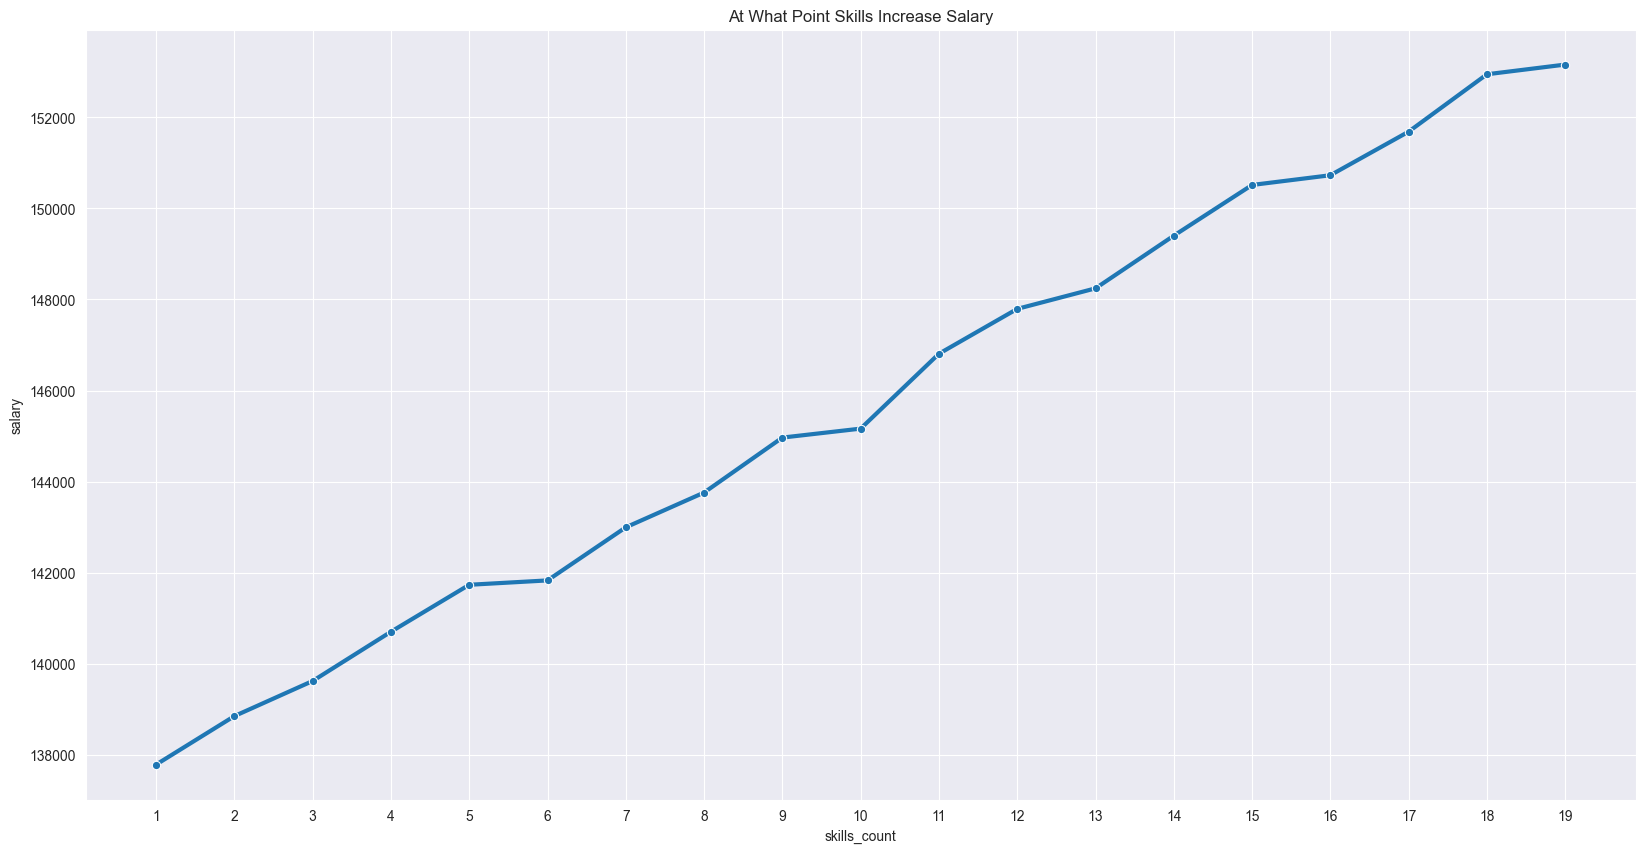

In [204]:
def skill_and_salary(df: pd.DataFrame):

    plt.figure(figsize=(20,10))
    # média salarial por quantidade de skills
    new_df = (
        df.groupby("skills_count")["salary"]
        .mean()
        .round(2)
        .reset_index()
        .sort_values("skills_count")
    )

    plt.title(
        "At What Point Skills Increase Salary"
    )

    # gráfico principal
    sns.lineplot(
        data=new_df,
        x="skills_count",
        y="salary",
        marker="o",
        linewidth=3,
        errorbar=None
    )

    plt.xticks(range(
        df["skills_count"].min(),
        df["skills_count"].max() + 1,
        1
    ))

    plt.show()

skill_and_salary(df)

Developing a broad skill set matters.

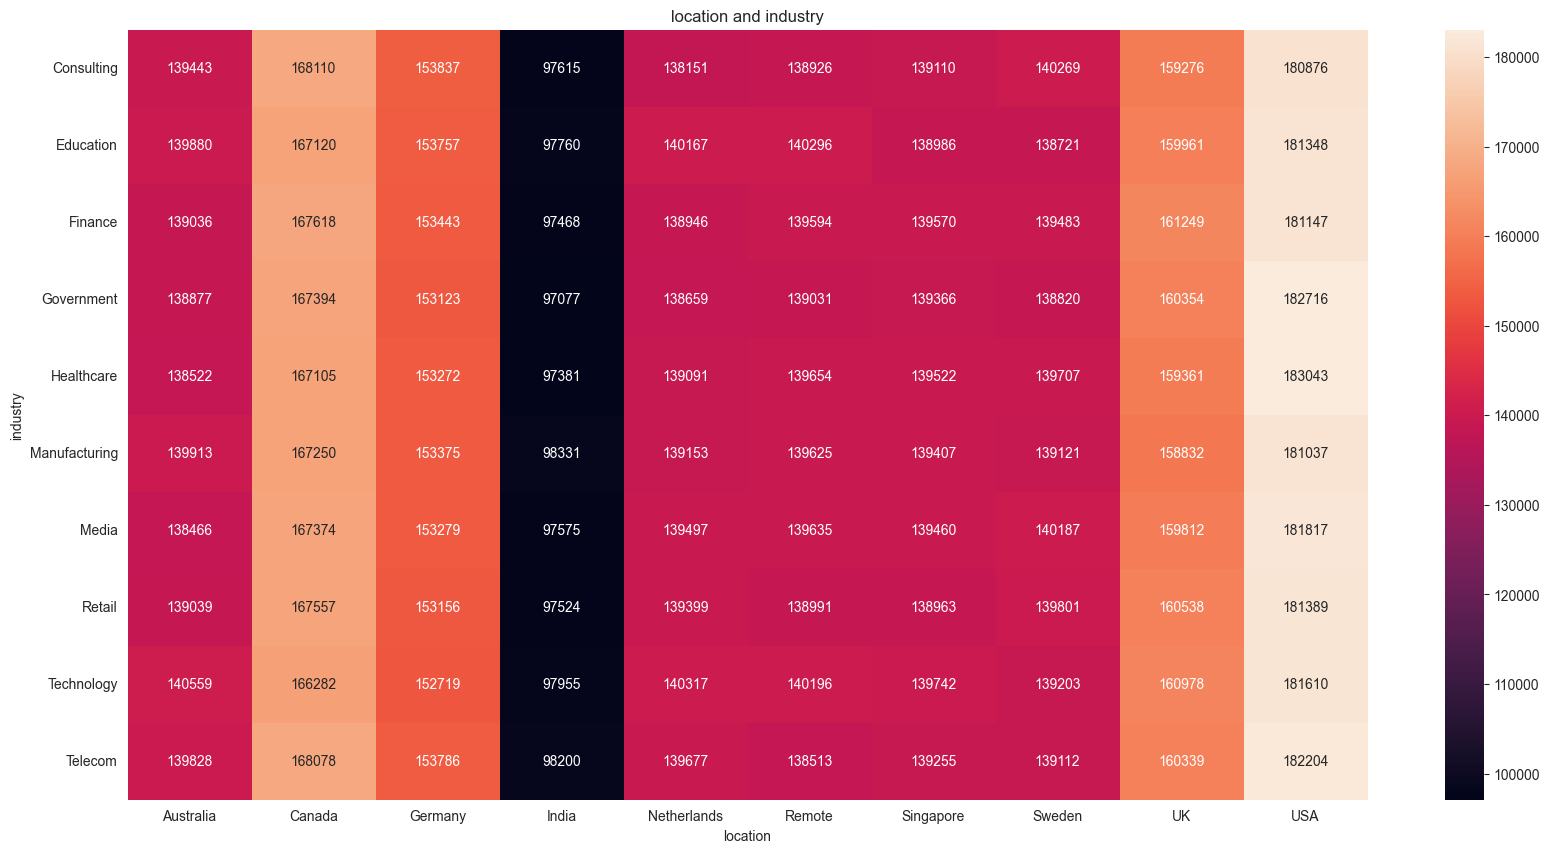

In [205]:
def salary_and_location_and_industry(df: pd.DataFrame):
    plt.figure(figsize=(20,10))
    
    new_df = (
            df.groupby(["industry", "location"])["salary"]
            .mean()
            .round(2)
            .reset_index()
            .sort_values("salary", ascending=True)
            )
    

    plt.title("location and industry")
    
    pivot = new_df.pivot_table(
        values="salary",
        index="industry",
        columns="location",
        aggfunc="mean"
    )
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f"
    )
    
    plt.show()

salary_and_location_and_industry(df)


Technology and Telecom dominate salary rankings worldwide, while location remains a major determinan developed economies and remote work consistently yield higher compensation.

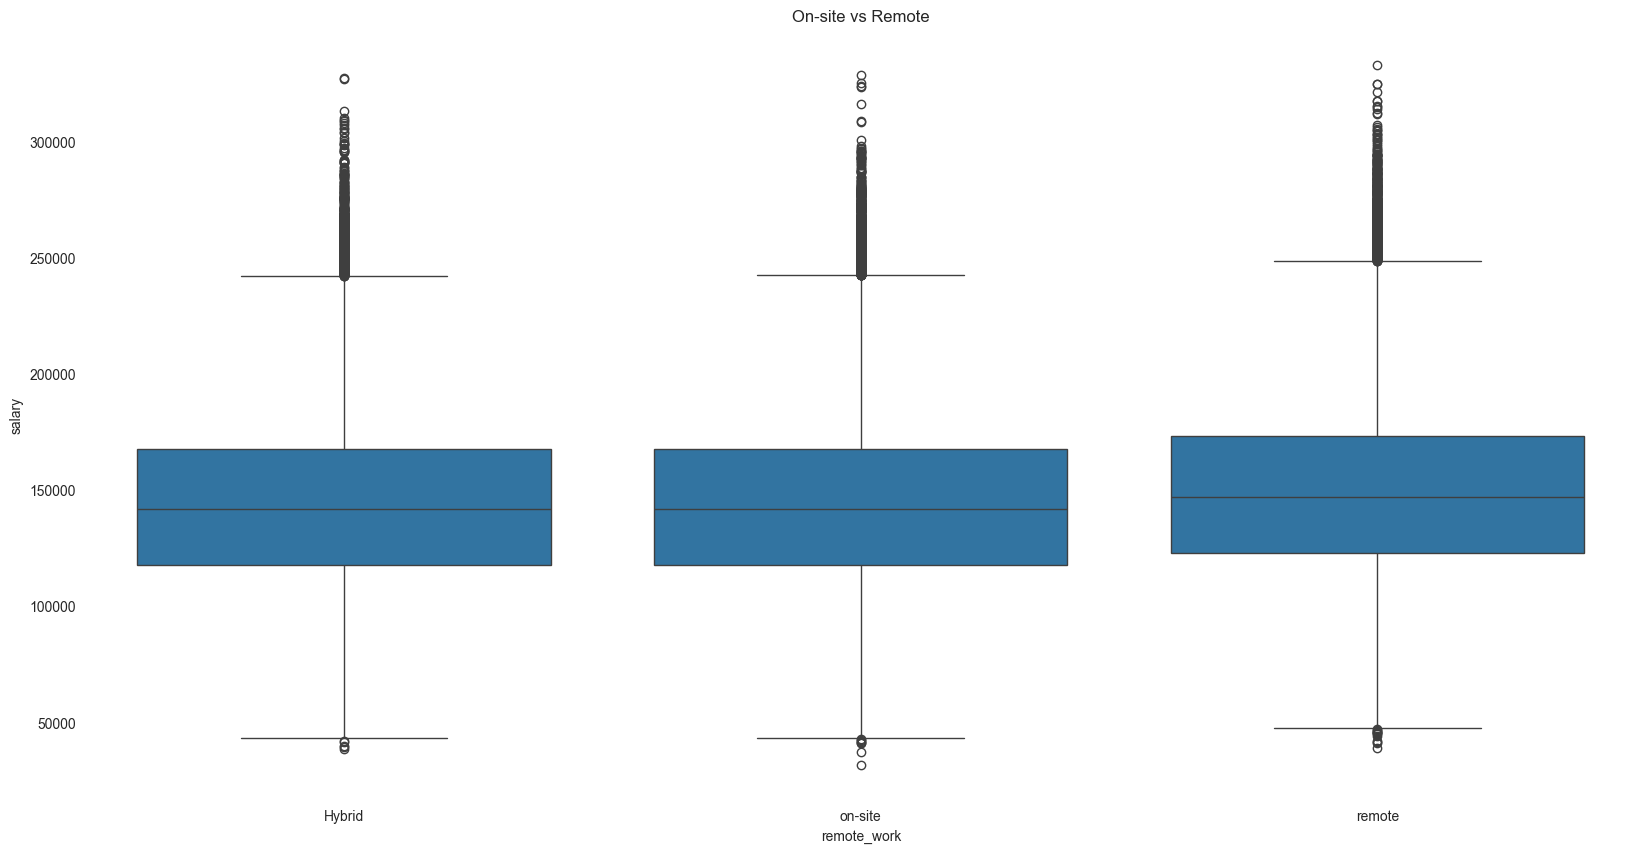

In [217]:
def onsite_vs_remote(df: pd.DataFrame):
    plt.figure(figsize=(20,10))
    plt.title("Onsite vs remote")
    #separando todas as profissoes e escolhendo uma cor em formato RGB
    data = unique_data_color_and_job(df)
    df["remote_work"] = df["remote_work"].replace({
        "No": "on-site",
        "Yes": "remote"
        })
    
    plt.title("On-site vs Remote")
    
    sns.boxplot(
    data=df,
    x="remote_work",
    y="salary"
    )
    
    plt.box(False)
    plt.show()
    
onsite_vs_remote(df)

Remote work shows a slight overall relevance compared to on‑site work at the same experience level.

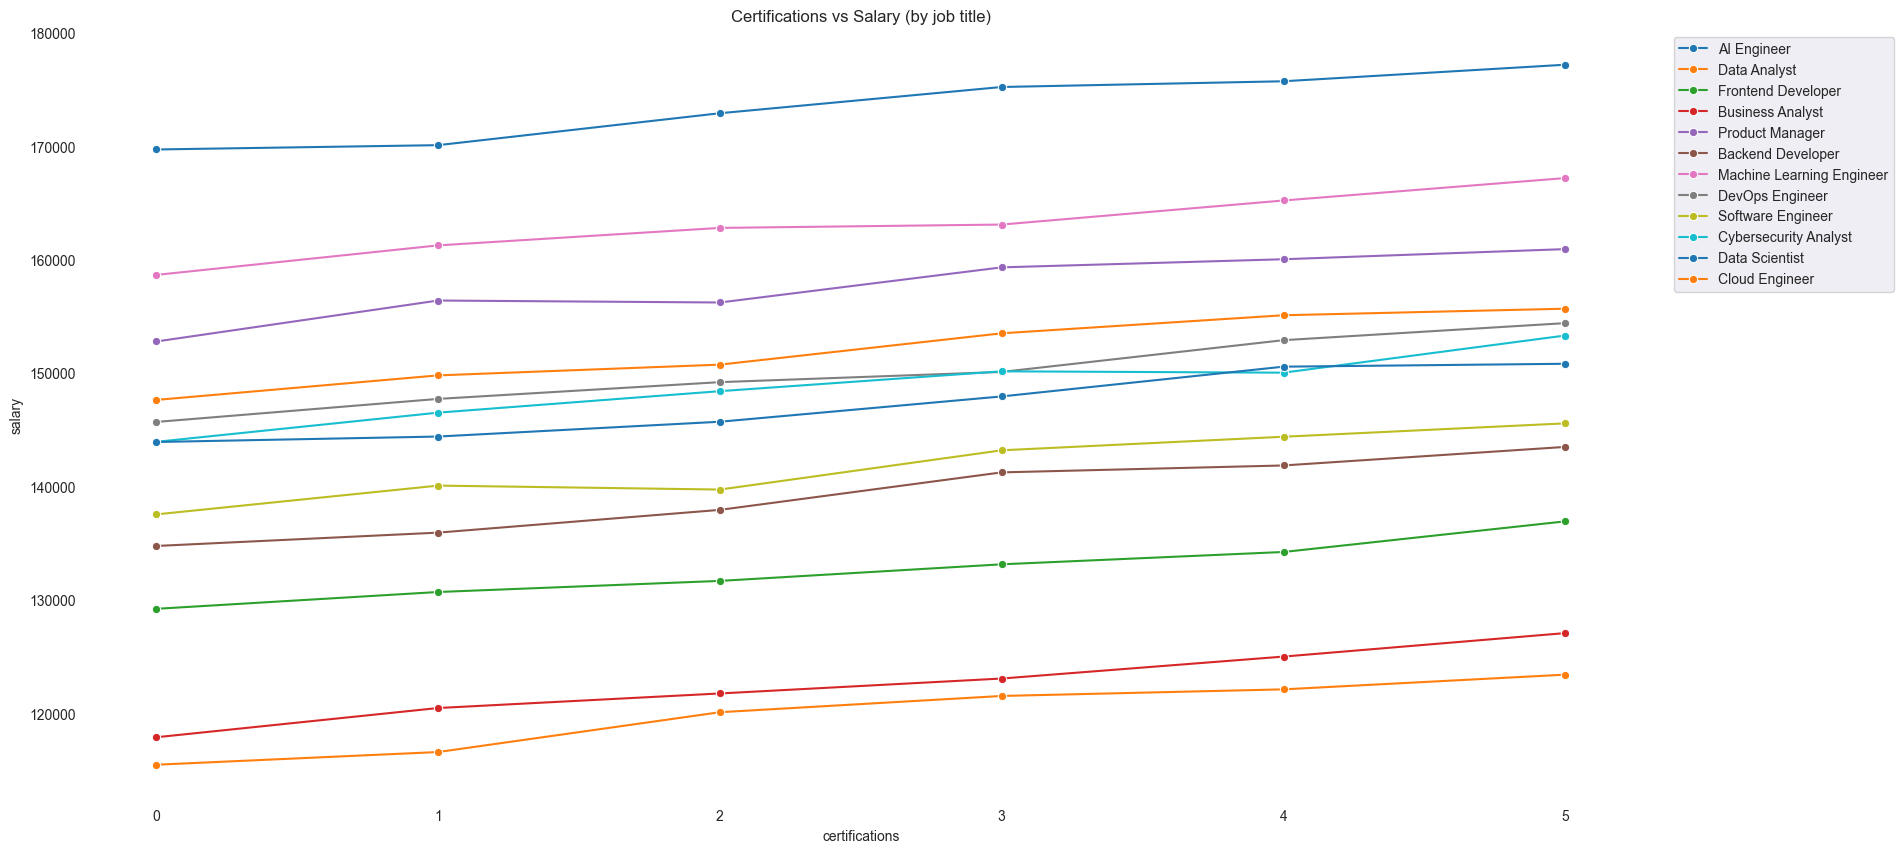

In [223]:
def certifications_and_salary(df: pd.DataFrame):

    plt.figure(figsize=(20,10))

    jobs = df["job_title"].unique()
    colors = sns.color_palette("tab10", len(jobs))

    for job, color in zip(jobs, colors):

        temp = df[df["job_title"] == job]

        new_df = (
            temp.groupby("certifications")["salary"]
            .mean()
            .reset_index()
            .sort_values("certifications")
        )

        sns.lineplot(
            data=new_df,
            x="certifications",
            y="salary",
            color=color,
            label=job,
            marker="o",
            errorbar=None
        )

    plt.title("Certifications vs Salary (by job title)")

    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.box(False)
    plt.show()
    
certifications_and_salary(df)